assuming that the dataset is linear, allows us to use linear regression. in cleaned dataset consisted of a sample of 21615 house and 14 features for each house and the target variable will be the price. this results in n being the number of sample = 21615 and the number of features, m = 15 with the target ,y = price and the number of weights, w, equal to the number of features,

this results in a feature matrix ,X, of size n * m and a y matrix of size 1*m, and , w is a 1*m matrix.. however in order to perform the dot product of x and w, the diemsion must be equal, the number of rows in x must be equal to the number of columns in w so we transpose x resulting in a m*n matrix where each column is now an indidual house sample and each row is now a all the sample values for that feature. this transposed x matrix benoted by, mT will be used in linear regression.

since we assumed the dataset is linear, that means we will be using straight line denoted by the eqn mx+c =y but for this prediction it is alterd to be w*xT +c = y_pred this is because we will be multiplying the transposed x matrix by the weights + c (a constant for the y intercept).

then we will bw using MSE, mean square error, to caluculte the loss of the prediction, using the eqn (y - y_pred)sq, subbin y_pred = (y - w*xT +c)sq. we will then take the averge of all the MSE for a more generalised and nummical stable output while also minimizing the w and c used. while predicting the house prices in Seattle for the time 2014-2015, y_pred will be the value we wish to find, inorder for y_pred to be useful we will first need to calculate the weights and bias for the model to make these prediction.

since the loss_function/MSE is not a linear eqn but a quadratic function, it is non-linear. since it a qudartic, all quadratic curves are parabolas meaning they are differenciable as well as continious and since all parabolas have only one global minimun point, it makes it easier as to having a curve with local min point and checking if the program converged to a local instead of a minuimn, allowing us to use gradient decent to find the minimun point.

note there is a hypothese that PCA dimension reduction would work with this data set to improve accuracy however may not be implemented due to deadline as well as feature engineering.

tensor([-8.2975e-02,  1.0031e-01, -2.4347e-01, -9.7363e-03,  1.8517e-04,
         1.3448e-01,  1.1156e-01,  4.5254e-02,  3.2329e-01,  6.4394e-01,
         3.0042e-01, -2.1349e-01,  2.1093e-01, -3.1052e-02]) tensor(-0.0023)
MSE 46293525304.63976
RMSE 215159.3021568897
MAE 128723.74949398566
R²: 0.6937787268055888


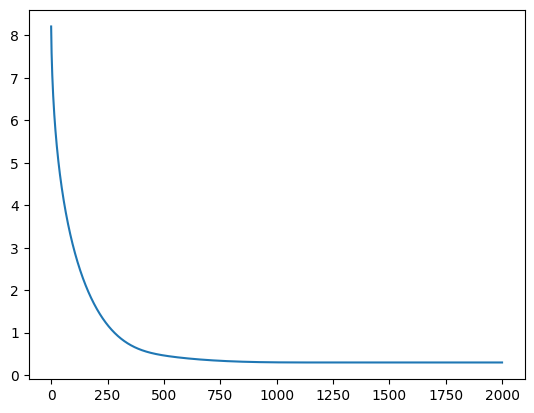

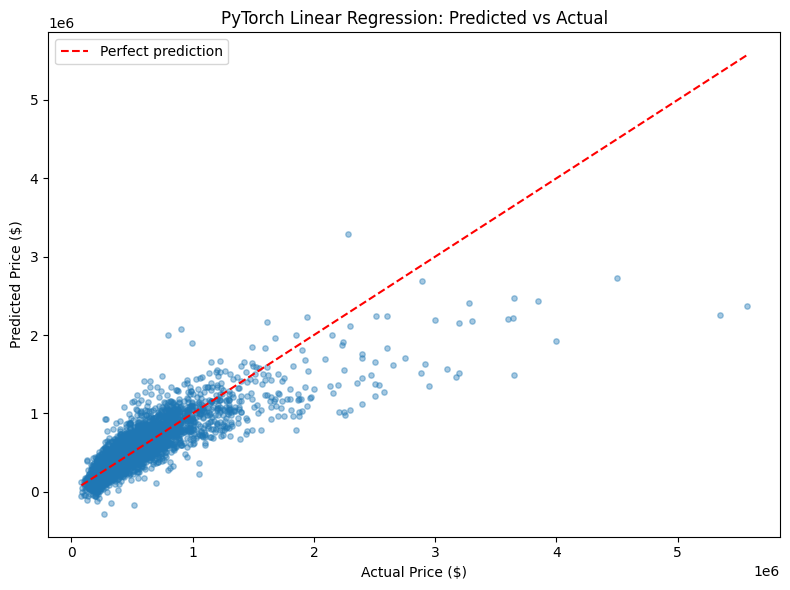

In [4]:

import numpy as np
import torch as th
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import sklearn.model_selection as selection
import matplotlib.pyplot as plt
from sklearn import metrics


# modelling the loss function as a MSE from pytorch as we will be working tensors and to prevent any incompatablity from an MSE function from other libaraies
mse = nn.MSELoss()
def loss_function(predictions, actual):
    return mse(predictions, actual)

#function to plot computation graph with gradient descent
def plot_loss(loss_curve):
    plt.plot(list(range(len(loss_curve))), loss_curve)

# defining the Linear Regression model with weight and constant variables
class LinearRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        w = th.tensor(np.random.random(size=n_features), dtype=th.float32)
        c = th.tensor(np.random.random(), dtype=th.float32)
        self.w = nn.Parameter(w)
        self.c = nn.Parameter(c)

    def predict(self, X):
     #transponsing the feature matix so that it can be use to find the dot product of w and x
        return self.w @ th.transpose(X, 0, 1) + self.c


    def forward(self, X):
        return self.predict(X)

    #calculates the loss of a pridiction by calling the loss_function
    def loss(self, X, y):
        predictions = self.predict(X)
        return loss_function(predictions, y)

# then nmber of columns ncols,features, and the number of row nrows, sample house
nrows, ncols = X.shape
#with the data being scaled, it produce large numbers, indicating numerical instablity
y_scaled = (y - y.mean()) / y.std()

#splitting the dataset into training and testing sets using a 80/20 split with random selection
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42,shuffle=True)

#the dataset were in pandas serires while torch requires numpy array to convert to tensors
X_train =X_train.to_numpy()
X_test =X_test.to_numpy()

#converting the x training and test data to tensors so develop the computational graph
X_train = th.tensor(X_train, dtype=th.float32)
y_train = th.tensor(y_train, dtype=th.float32)

#assigning the linear regression model
model = LinearRegression(ncols)
#learning 01rates were tested but anything lr less that 0.05 was within .1 of the miniume value
lr = 0.001
# Modified SGD
optimizer = optim.RMSprop(model.parameters(), lr=lr) D
num_iters = 2000
loss_curve = []

for i in range(num_iters):
    optimizer.zero_grad()
    loss_value = model.loss(X_train, y_train)
    loss_curve.append(loss_value.data.item())
    loss_value.backward()
    optimizer.step()

plot_loss(loss_curve)
w = model.w.detach()
c = model.c.detach()
print(w, c)

X_test = th.tensor(X_test, dtype=th.float32)
predictions = model.predict(X_test)
predictions = predictions.clone().detach()

y_pred_real = predictions * y.std() + y.mean()
y_test_real = y_test * y.std() + y.mean()


print("MSE", metrics.mean_squared_error(y_test_real, y_pred_real))
print("RMSE", metrics.root_mean_squared_error(y_test_real, y_pred_real))
print("MAE", metrics.mean_absolute_error(y_test_real, y_pred_real))
print("R²:", metrics.r2_score(y_test_real, y_pred_real))


plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.4, s=15)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         'r--', label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('PyTorch Linear Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

from our results, the mean square error was very large approximately 46 billion, which when working with prices of hunderds of thoursand which are then squared can happen making this less interpretable as it represents dollars.

However the root mean square error, sq_root(mse), explains that our model was off by $215 159 on averge when prdicting houses but when squaring the values they are susceptible to outliars, which the dataset has, visible in the scatter plot.

the r_sq value of 0.69 showed that our model predicts 69%  of the variance of the dataset

from these results we can conclude the model predicted fairly well.

limitation : the inclusion of outliars




implementing pca

torch.Size([17290, 14])
Original features: 14
PCA features (95% variance): 11
Reduction: 21% fewer features


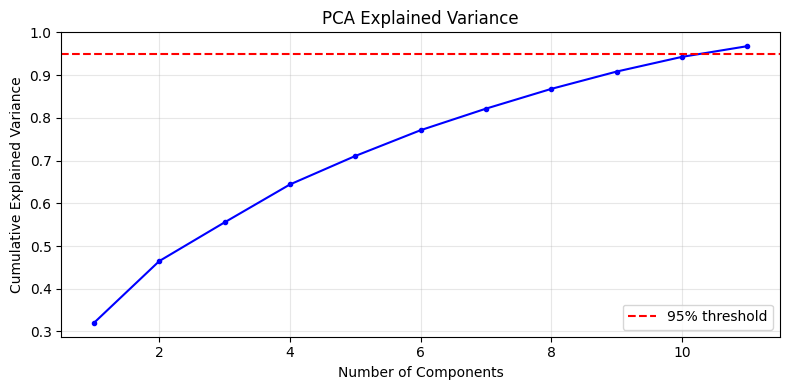

PCA-reduced data ready for experiments in Part 2


In [11]:
from sklearn.decomposition import PCA

#fitting pca on the training data while keeping 95% of variance
pca =PCA(n_components=0.95)

X_train_pca= pca.fit_transform(X_train)

X_test_pca =pca.transform(X_test)

print(f'Original features: {X_train.shape[1]}')
print(f'PCA features (95% variance): {X_train_pca.shape[1]}')
print(f'Reduction: {1 - X_train_pca.shape[1]/X_train.shape[1]:.0%} fewer features')

plt.figure(figsize=(8, 4))
cumulative = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative)+1), cumulative, 'b.-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tensor([ 0.2880,  0.2892,  0.1612,  0.0860,  0.2273,  0.1213,  0.0059, -0.0196,
         0.1213, -0.2334, -0.0740]) tensor(-0.0063)
MSE 46387517689.47224
RMSE 215377.61650058307
MAE 128973.76368407356
R²: 0.6931569882889265


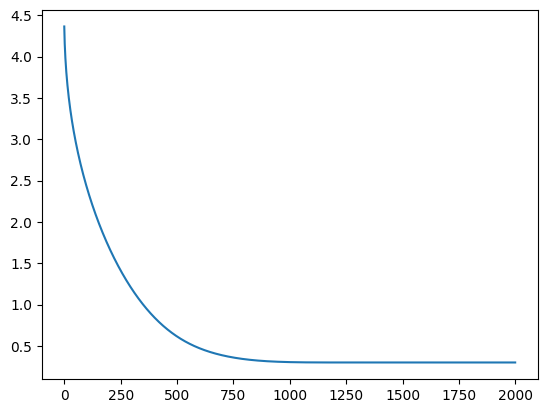

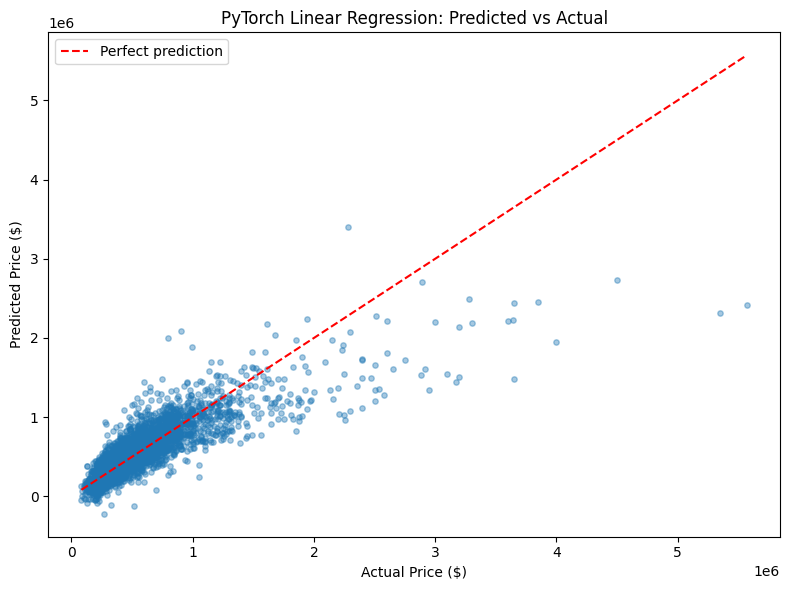

In [22]:
#converting the x training and test data to tensors so develop the computational graph
X_trainp = th.tensor(X_train_pca, dtype=th.float32)
y_train = th.tensor(y_train, dtype=th.float32)

#assigning the linear regression model
model1 = LinearRegression(X_train_pca.shape[1])
#learning 01rates were tested but anything lr less that 0.05 was within .1 of the miniume value
lr = 0.001
# Modified SGD
optimizer = optim.RMSprop(model1.parameters(), lr=lr)
num_iters = 2000
loss_curve = []

for i in range(num_iters):
    optimizer.zero_grad()
    loss_value = model1.loss(X_trainp, y_train)
    loss_curve.append(loss_value.data.item())
    loss_value.backward()
    optimizer.step()

plot_loss(loss_curve)
w = model1.w.detach()
c = model1.c.detach()
print(w, c)

X_test = th.tensor(X_test_pca, dtype=th.float32)
predictions = model1.predict(X_test)
predictions = predictions.clone().detach()

y_pred_real = predictions * y.std() + y.mean()
y_test_real = y_test * y.std() + y.mean()

print("MSE", metrics.mean_squared_error(y_test_real,y_pred_real))
print("RMSE", metrics.root_mean_squared_error(y_test_real,y_pred_real))
print("MAE", metrics.mean_absolute_error(y_test_real,y_pred_real))
print("R²:", metrics.r2_score(y_test_real,y_pred_real))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.4, s=15)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         'r--', label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('PyTorch Linear Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

from our results with pca , the mean square error was  still very large and  approximately the same, 46 billion

the root mean square error, sq_root(mse), did have a slight increase which that our model was off by 215 377 instead of 215 159 on average

the r_sq value was approximately the same of 0.69 showing that our model still predicts 69% of the variance of the dataset

from these results are approximately the same, this is with a 21% reduction in features of the dataset allowing less time and resourses where used compared to without PCA we can conclude the model still predicted fairly well.

limitation : the inclusion of outliars

